# Сегментация: предсказания моделей из `data/weights`

Берёт чекпоинты из `data/weights/`, прогоняет модели по картинкам Cityscapes
и показывает в одной строке:

| изображение | разметка (если есть) | учитель | ученик | карты ошибок |
|---|---|---|---|---|

Правила:

* **разметка** показывается только там, где она есть: для `train`/`val` Cityscapes —
  всегда, для произвольной папки с картинками (`IMAGES_DIR`) — нет, и тогда
  метрики не считаются;
* **ученик** появляется, только если задан второй чекпоинт. Одна модель — одна колонка
  предсказаний;
* если чекпоинты не указаны явно, берутся первые найденные в `data/weights/`
  (первый — учитель, второй — ученик).

Чекпоинты — те, что пишет `SegmentationTrainer` (`best.pt` / `last.pt`, веса лежат
под ключом `student_state`); голый `state_dict` тоже понимается.

In [15]:
%matplotlib inline

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "configs").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "configs").is_dir():
    raise RuntimeError(
        "Не найден корень репозитория (каталог configs/). "
        "Запусти ноутбук изнутри репозитория Juicer-for-models."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Корень репозитория:", REPO_ROOT)

Корень репозитория: /home/m.obukhov/Juicer-for-models


In [16]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from matplotlib.patches import Patch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset
from torchvision.transforms.functional import pil_to_tensor

from src.data.datasets import CITYSCAPES_SEGMENTATION_CLASSES, CityscapesSegmentation
from src.utils import resolve_device
from src.utils.metrics import IoUAccumulator, count_parameters

## Параметры

Единственная ячейка, которую нужно править.

`*_WEIGHTS` — имя файла внутри `WEIGHTS_DIR`, путь от корня репозитория или
абсолютный путь. `None` в обоих — автоподбор из `WEIGHTS_DIR`.
Если архитектура ученика отличается от дефолтной, это правится через
`*_MODEL` (имя конфига из `configs/model/student/`) и `*_OVERRIDES`
(например `["model.student.base_channels=32"]`).

In [17]:
WEIGHTS_DIR = "data/weights"

TEACHER_WEIGHTS = '3.pt'                 # напр. "cityscapes_unet_best.pt"
TEACHER_MODEL = "unet"                 # конфиг из configs/model/student/
TEACHER_OVERRIDES: list[str] = []      # напр. ["model.student.base_channels=64"]
TEACHER_TITLE = "учитель"

STUDENT_WEIGHTS = '4.pt'               # None -> ученика не будет
STUDENT_MODEL = "unet"
STUDENT_OVERRIDES: list[str] = []
STUDENT_TITLE = "ученик"

# Автоподбор работает, только если оба *_WEIGHTS равны None.
AUTO_DISCOVER = True

SPLIT = "val"           # "train" | "val" — на чём смотреть
COUNT = 3               # сколько картинок показать
SEED = 0                # None -> каждый запуск новые картинки
INDICES = None          # напр. [0, 17] -> показать эти индексы вместо случайных
IMAGES_DIR = None       # папка с картинками без разметки; тогда SPLIT игнорируется

# None -> родное разрешение 1024x2048, как на валидации в трейнере.
# На CPU или маленькой видеокарте ставь [512, 1024] (сторона должна делиться
# на 2**depth = 16, иначе skip-связи U-Net не сойдутся по размеру).
EVAL_IMAGE_SIZE = None

DEVICE = "auto"         # "auto" | "cuda" | "cuda:0" | "cpu"
AMP = True              # autocast на cuda; на cpu игнорируется
WEIGHTS_ONLY = True     # torch.load(weights_only=...); False — только для своих файлов

ALPHA = 0.55            # прозрачность маски поверх картинки
LEGEND = "present"      # "present" | "all" | "none"
SHOW_ERRORS = True      # колонка «где модель ошиблась» (нужна разметка)
SAVE_PATH = None        # напр. REPO_ROOT / "outputs" / "predictions.png"

EXTRA_OVERRIDES: list[str] = []

DEFAULT_OVERRIDES = [
    "data/dataset=cityscapes_seg",
    "data/transform/train=cityscapes_seg_transform",
    "data/transform/eval=cityscapes_seg_transform",
    "task_type=segmentation",
]

## Палитра и вспомогательные функции

In [18]:
CITYSCAPES_PALETTE = (
    (128, 64, 128),   # road
    (244, 35, 232),   # sidewalk
    (70, 70, 70),     # building
    (102, 102, 156),  # wall
    (190, 153, 153),  # fence
    (153, 153, 153),  # pole
    (250, 170, 30),   # traffic light
    (220, 220, 0),    # traffic sign
    (107, 142, 35),   # vegetation
    (152, 251, 152),  # terrain
    (70, 130, 180),   # sky
    (220, 20, 60),    # person
    (255, 0, 0),      # rider
    (0, 0, 142),      # car
    (0, 0, 70),       # truck
    (0, 60, 100),     # bus
    (0, 80, 100),     # train
    (0, 0, 230),      # motorcycle
    (119, 11, 32),    # bicycle
)

IGNORE_COLOR = (0, 0, 0)
ERROR_COLOR = (230, 57, 53)

# Цвета серий для сравнения моделей (слоты 1-2 валидированной палитры).
SERIES_COLORS = ("#2a78d6", "#eb6834", "#1baf7a")


def build_color_lut() -> np.ndarray:
    lut = np.full((256, 3), IGNORE_COLOR, dtype=np.uint8)
    for train_id, color in enumerate(CITYSCAPES_PALETTE):
        lut[train_id] = color
    return lut


def colorize_mask(mask: torch.Tensor, lut: np.ndarray) -> np.ndarray:
    values = mask.detach().cpu().numpy()
    if values.dtype != np.uint8:
        values = np.clip(values, 0, 255).astype(np.uint8)
    return lut[values]


def to_uint8_image(image: torch.Tensor, mean=None, std=None) -> np.ndarray:
    image = image.detach().float().cpu()

    if mean is not None and std is not None:
        mean_tensor = torch.tensor(mean).view(-1, 1, 1)
        std_tensor = torch.tensor(std).view(-1, 1, 1)
        image = image * std_tensor + mean_tensor

    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return (image * 255).round().astype(np.uint8)


def blend(image, color_mask, alpha=0.55, valid=None) -> np.ndarray:
    mixed = (1 - alpha) * image.astype(np.float32) + alpha * color_mask.astype(np.float32)
    mixed = mixed.round().clip(0, 255).astype(np.uint8)

    if valid is not None:
        mixed = np.where(valid[..., None], mixed, image)

    return mixed


def error_overlay(image: np.ndarray, prediction: torch.Tensor, mask: torch.Tensor,
                  ignore_index: int, alpha: float = 0.8):
    """Красным — пиксели, где модель ошиблась. Void не считается ошибкой.

    Возвращает (картинка, доля ошибок среди размеченных пикселей в %).
    """
    labeled = (mask != ignore_index)
    wrong = ((prediction != mask) & labeled).cpu().numpy()

    gray = image.mean(axis=2, keepdims=True).repeat(3, axis=2).astype(np.float32)
    red = np.array(ERROR_COLOR, dtype=np.float32)
    painted = (alpha * red + (1 - alpha) * gray).round().clip(0, 255).astype(np.uint8)

    picture = np.where(wrong[..., None], painted, gray.astype(np.uint8))
    share = 100 * wrong.sum() / max(int(labeled.sum()), 1)

    return picture, share


def mask_class_shares(mask: torch.Tensor) -> dict[int, float]:
    total = mask.numel()
    values, counts = torch.unique(mask, return_counts=True)
    pairs = sorted(zip(values.tolist(), counts.tolist()), key=lambda pair: -pair[1])
    return {value: count / total for value, count in pairs}


def add_class_legend(figure, train_ids, ignore_index: int, show_ignore: bool = True) -> None:
    handles = [
        Patch(
            facecolor=np.array(CITYSCAPES_PALETTE[train_id]) / 255,
            edgecolor="0.6",
            label=CITYSCAPES_SEGMENTATION_CLASSES[train_id],
        )
        for train_id in train_ids
        if 0 <= train_id < len(CITYSCAPES_PALETTE)
    ]

    if show_ignore:
        handles.append(
            Patch(
                facecolor=np.array(IGNORE_COLOR) / 255,
                edgecolor="0.6",
                label=f"IGNORE ({ignore_index}), не наложен",
            )
        )

    if handles:
        figure.legend(
            handles=handles,
            loc="lower center",
            ncol=min(7, len(handles)),
            fontsize=8,
            frameon=False,
        )


LUT = build_color_lut()

## Конфиг и устройство

In [19]:
GlobalHydra.instance().clear()
with initialize_config_dir(version_base="1.3", config_dir=str(REPO_ROOT / "configs")):
    cfg = compose(config_name="config", overrides=DEFAULT_OVERRIDES + EXTRA_OVERRIDES)

MEAN = list(cfg.data.dataset.normalize.mean)
STD = list(cfg.data.dataset.normalize.std)
IGNORE_INDEX = int(cfg.data.dataset.ignore_index)
NUM_CLASSES = int(cfg.data.dataset.num_classes)

DATA_ROOT = Path(cfg.data.dataset.build.root)
if not DATA_ROOT.is_absolute():
    DATA_ROOT = REPO_ROOT / DATA_ROOT

device = resolve_device(DEVICE)
amp_enabled = AMP and device.type == "cuda"

print(f"Устройство: {device} | autocast: {amp_enabled}")
print(f"Классов: {NUM_CLASSES}, ignore_index: {IGNORE_INDEX}")
print(f"Разрешение инференса: {EVAL_IMAGE_SIZE or 'родное (как на валидации)'}")

if device.type == "cpu" and EVAL_IMAGE_SIZE is None:
    print(
        "\nВнимание: полный кадр 1024x2048 на CPU считается минутами. "
        "Поставь EVAL_IMAGE_SIZE = [512, 1024]."
    )

Устройство: cuda | autocast: True
Классов: 19, ignore_index: 255
Разрешение инференса: родное (как на валидации)


## Что лежит в `data/weights`

Ячейка ничего не загружает в модель — только смотрит, что за файлы есть и что
внутри: под каким ключом веса, с какой эпохи, с каким mIoU.

In [20]:
CHECKPOINT_SUFFIXES = {".pt", ".pth", ".ckpt"}
STATE_DICT_KEYS = ("student_state", "model_state_dict", "state_dict", "model", "teacher_state")

WEIGHTS_ROOT = Path(WEIGHTS_DIR)
if not WEIGHTS_ROOT.is_absolute():
    WEIGHTS_ROOT = REPO_ROOT / WEIGHTS_ROOT


def find_checkpoints(directory: Path) -> list[Path]:
    if not directory.is_dir():
        return []
    return sorted(
        path
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in CHECKPOINT_SUFFIXES
    )


def extract_state_dict(checkpoint) -> tuple[str, dict]:
    """(имя ключа, веса). Понимает и чекпоинт трейнера, и голый state_dict."""
    if not isinstance(checkpoint, dict):
        raise TypeError(f"Ожидался dict, получено {type(checkpoint)}")

    for key in STATE_DICT_KEYS:
        value = checkpoint.get(key)
        if isinstance(value, dict) and value:
            return key, value

    if checkpoint and all(isinstance(value, torch.Tensor) for value in checkpoint.values()):
        return "<сам файл>", checkpoint

    raise KeyError(
        f"Не нашёл веса в чекпоинте. Ключи верхнего уровня: {list(checkpoint)[:10]}"
    )


def load_checkpoint(path: Path):
    return torch.load(path, map_location="cpu", weights_only=WEIGHTS_ONLY)


def describe_checkpoint(path: Path) -> dict:
    checkpoint = load_checkpoint(path)
    key, state_dict = extract_state_dict(checkpoint)

    row = {
        "файл": str(path.relative_to(WEIGHTS_ROOT)) if path.is_relative_to(WEIGHTS_ROOT) else str(path),
        "МБ": round(path.stat().st_size / 1024 ** 2, 1),
        "ключ весов": key,
        "тензоров": len(state_dict),
        "параметров, M": round(sum(t.numel() for t in state_dict.values()) / 1e6, 2),
    }

    if isinstance(checkpoint, dict):
        for extra in ("epoch", "best_miou", "best_acc", "best_map"):
            if extra in checkpoint and not isinstance(checkpoint[extra], dict):
                row[extra] = checkpoint[extra]

    return row


CHECKPOINTS = find_checkpoints(WEIGHTS_ROOT)

print("Каталог весов:", WEIGHTS_ROOT)
if CHECKPOINTS:
    display(pd.DataFrame([describe_checkpoint(path) for path in CHECKPOINTS]))
else:
    print(
        "Чекпоинтов не найдено. Положи сюда best.pt/last.pt из outputs/<эксперимент>/<запуск>/ "
        "или укажи путь в TEACHER_WEIGHTS."
    )

Каталог весов: /home/m.obukhov/Juicer-for-models/data/weights


,файл,МБ,ключ весов,тензоров,"параметров, M",epoch,best_miou
0,1.pt,355.3,student_state,118,31.05,94,0.531727
1,2.pt,355.3,student_state,118,31.05,95,0.533492
2,3.pt,236.9,student_state,118,31.05,97,0.469581
3,4.pt,236.9,student_state,118,31.05,96,0.448881


## Какие модели показываем

In [21]:
def resolve_weights(spec) -> Path | None:
    """Имя файла в WEIGHTS_DIR, путь от корня репозитория или абсолютный путь."""
    if spec is None:
        return None

    path = Path(spec)
    candidates = [path, WEIGHTS_ROOT / path, REPO_ROOT / path]

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    raise FileNotFoundError(f"Чекпоинт не найден: {spec} (искал в {[str(c) for c in candidates]})")


teacher_path = resolve_weights(TEACHER_WEIGHTS)
student_path = resolve_weights(STUDENT_WEIGHTS)

if AUTO_DISCOVER and TEACHER_WEIGHTS is None and STUDENT_WEIGHTS is None:
    teacher_path = CHECKPOINTS[0] if CHECKPOINTS else None
    student_path = CHECKPOINTS[1] if len(CHECKPOINTS) > 1 else None
    print("Автоподбор из", WEIGHTS_ROOT)

model_specs = []
if teacher_path is not None:
    model_specs.append(
        {"title": TEACHER_TITLE, "path": teacher_path,
         "model": TEACHER_MODEL, "overrides": list(TEACHER_OVERRIDES)}
    )
if student_path is not None:
    model_specs.append(
        {"title": STUDENT_TITLE, "path": student_path,
         "model": STUDENT_MODEL, "overrides": list(STUDENT_OVERRIDES)}
    )

if not model_specs:
    raise RuntimeError(
        f"Не задано ни одной модели. Положи чекпоинт в {WEIGHTS_ROOT} "
        f"или укажи TEACHER_WEIGHTS вручную."
    )

for spec in model_specs:
    print(f"  {spec['title']:<10} {spec['model']:<8} {spec['path']}")

if len(model_specs) == 1:
    print("\nВторой модели нет — колонка ученика не рисуется.")

  учитель    unet     /home/m.obukhov/Juicer-for-models/data/weights/3.pt
  ученик     unet     /home/m.obukhov/Juicer-for-models/data/weights/4.pt


## Загрузка моделей

Модель собирается конфигом (`configs/model/student/<имя>.yaml`), а не руками:
так архитектура гарантированно та же, что была в обучении, включая `num_classes`
из конфига датасета. Веса грузятся с `strict=False`, но расхождения печатаются —
молча подгруженная наполовину модель хуже, чем явная ошибка.

In [22]:
def build_model(model_name: str, overrides: list[str]) -> nn.Module:
    """Инстанцирует модель из configs/model/student/<model_name>.yaml."""
    GlobalHydra.instance().clear()
    with initialize_config_dir(version_base="1.3", config_dir=str(REPO_ROOT / "configs")):
        model_cfg = compose(
            config_name="config",
            overrides=DEFAULT_OVERRIDES + [f"model/student={model_name}"] + EXTRA_OVERRIDES + overrides,
        )

    return instantiate(model_cfg.model.student)


def load_segmentation_model(spec: dict) -> nn.Module:
    model = build_model(spec["model"], spec["overrides"])

    checkpoint = load_checkpoint(spec["path"])
    key, state_dict = extract_state_dict(checkpoint)
    # DataParallel дописывает "module." к каждому ключу.
    state_dict = {name.removeprefix("module."): tensor for name, tensor in state_dict.items()}

    result = model.load_state_dict(state_dict, strict=False)

    print(f"[{spec['title']}] {spec['path'].name}: веса из ключа {key}")
    if isinstance(checkpoint, dict):
        epoch = checkpoint.get("epoch")
        best_miou = checkpoint.get("best_miou")
        if epoch is not None:
            print(f"    эпоха {epoch}" + (f", best mIoU {best_miou:.4f}" if best_miou is not None else ""))

    if result.missing_keys or result.unexpected_keys:
        print(
            f"    ВНИМАНИЕ: не совпало {len(result.missing_keys)} ключей модели "
            f"и {len(result.unexpected_keys)} ключей чекпоинта."
        )
        print(f"    нет в чекпоинте: {result.missing_keys[:5]}")
        print(f"    лишние в чекпоинте: {result.unexpected_keys[:5]}")
        print("    Скорее всего не та архитектура: проверь *_MODEL и *_OVERRIDES.")

    parameters = count_parameters(model)
    print(f"    параметров: {parameters['total_M']:.2f}M ({parameters['size_MiB']:.0f} MiB)")

    return model.to(device).eval()


models = {spec["title"]: load_segmentation_model(spec) for spec in model_specs}

[учитель] 3.pt: веса из ключа student_state
    эпоха 97, best mIoU 0.4696
    параметров: 31.04M (118 MiB)
[ученик] 4.pt: веса из ключа student_state
    эпоха 96, best mIoU 0.4489
    параметров: 31.04M (118 MiB)


## Датасет

`IMAGES_DIR = None` — Cityscapes с разметкой. Иначе произвольная папка с
картинками: предобработка та же (eval-трансформ), разметки нет, метрик нет.

In [23]:
class ImageFolderSegmentation(Dataset):
    """Папка с картинками без разметки. Возвращает (изображение, None)."""

    SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

    def __init__(self, root, transform=None, ignore_index: int = 255) -> None:
        root = Path(root)
        self.image_paths = sorted(
            path for path in root.rglob("*")
            if path.is_file() and path.suffix.lower() in self.SUFFIXES
        )
        if not self.image_paths:
            raise FileNotFoundError(f"В {root} не нашлось картинок")

        self.transform = transform
        self.ignore_index = ignore_index

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int):
        image = Image.open(self.image_paths[index]).convert("RGB")

        if self.transform is None:
            return pil_to_tensor(image).float() / 255.0, None

        # Трансформ сегментации работает с парой (картинка, маска). Подсовываем
        # заглушку из ignore_index и выбрасываем её: так предобработка картинки
        # гарантированно совпадает с валидационной.
        dummy_mask = torch.full((image.height, image.width), self.ignore_index, dtype=torch.uint8)
        image, _ = self.transform(image, dummy_mask)

        return image, None


transform_kwargs = {"image_size": EVAL_IMAGE_SIZE} if EVAL_IMAGE_SIZE is not None else {}
eval_transform = instantiate(cfg.data.transform.eval, **transform_kwargs)

if IMAGES_DIR is not None:
    images_root = Path(IMAGES_DIR)
    if not images_root.is_absolute():
        images_root = REPO_ROOT / images_root

    dataset = ImageFolderSegmentation(images_root, eval_transform, IGNORE_INDEX)
    HAS_MASKS = False
    print(f"Папка без разметки: {images_root} ({len(dataset)} картинок)")
else:
    dataset = CityscapesSegmentation(
        root=DATA_ROOT, split=SPLIT, transform=eval_transform, ignore_index=IGNORE_INDEX
    )
    HAS_MASKS = True
    print(f"Cityscapes {SPLIT}: {len(dataset)} изображений ({DATA_ROOT})")

if SEED is not None:
    random.seed(SEED)
    torch.manual_seed(SEED)

if INDICES is not None:
    out_of_range = [index for index in INDICES if not 0 <= index < len(dataset)]
    if out_of_range:
        raise ValueError(f"Индексы вне диапазона 0..{len(dataset) - 1}: {out_of_range}")
    sample_indices = list(INDICES)
else:
    if COUNT <= 0:
        raise ValueError(f"COUNT должен быть положительным, получено {COUNT}")
    sample_indices = random.sample(range(len(dataset)), min(COUNT, len(dataset)))

print("Показываем индексы:", sample_indices)

Cityscapes val: 500 изображений (/home/m.obukhov/Juicer-for-models/data/raw/cityscapes)
Показываем индексы: [432, 197, 388]


## Предсказания

`argmax` по логитам — та же операция, которой считается mIoU в
`segmentation_evaluate`, так что картинка соответствует метрике один в один.

In [24]:
@torch.no_grad()
def predict(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    """[C, H, W] -> карта классов [H, W] на cpu."""
    batch = image.unsqueeze(0).to(device, non_blocking=True)

    with torch.autocast(device.type, enabled=amp_enabled):
        output = model(batch)

    logits = output if isinstance(output, torch.Tensor) else getattr(output, "logits", None)
    if logits is None:
        raise TypeError(f"Модель вернула {type(output)}, из которого не достать логиты")

    logits = logits.float()
    # Архитектуры вроде DeepLab отдают логиты в пониженном разрешении.
    if logits.shape[-2:] != batch.shape[-2:]:
        logits = F.interpolate(logits, size=batch.shape[-2:], mode="bilinear", align_corners=False)

    return logits.argmax(dim=1)[0].cpu()


def image_metrics(prediction: torch.Tensor, mask: torch.Tensor) -> dict[str, float]:
    accumulator = IoUAccumulator(NUM_CLASSES, torch.device("cpu"), IGNORE_INDEX)
    accumulator.update(prediction, mask)
    return accumulator.compute()


samples = []

for position, index in enumerate(sample_indices, start=1):
    image, mask = dataset[index]
    height, width = image.shape[-2:]

    if height % 16 or width % 16:
        print(
            f"ВНИМАНИЕ: {width}x{height} не делится на 16 — U-Net с depth=4 упадёт "
            f"на конкатенации skip-связей. Поправь EVAL_IMAGE_SIZE."
        )

    name = f"{dataset.image_paths[index].parent.name}/{dataset.image_paths[index].name}"
    predictions, metrics = {}, {}

    for title, model in models.items():
        started = time.perf_counter()
        try:
            prediction = predict(model, image)
        except torch.OutOfMemoryError:
            raise RuntimeError(
                f"Не хватило видеопамяти на {width}x{height}. "
                f"Поставь EVAL_IMAGE_SIZE = [512, 1024] или DEVICE = 'cpu'."
            ) from None

        predictions[title] = prediction
        elapsed = time.perf_counter() - started

        if mask is not None:
            metrics[title] = image_metrics(prediction, mask)
            print(
                f"[{position}/{len(sample_indices)}] {name} | {title}: "
                f"mIoU {metrics[title]['miou']:.4f}, pixel acc {metrics[title]['pixel_acc']:.4f} "
                f"({elapsed:.1f} с)"
            )
        else:
            print(f"[{position}/{len(sample_indices)}] {name} | {title}: {elapsed:.1f} с")

    samples.append(
        {
            "index": index,
            "name": name,
            "image": image,
            "mask": mask,
            "predictions": predictions,
            "metrics": metrics,
        }
    )

print(f"\nГотово: {len(samples)} изображений x {len(models)} модел(и/ей)")

[1/3] munster/munster_000106_000019_leftImg8bit.png | учитель: mIoU 0.6319, pixel acc 0.9694 (0.1 с)
[1/3] munster/munster_000106_000019_leftImg8bit.png | ученик: mIoU 0.6072, pixel acc 0.9657 (0.1 с)
[2/3] frankfurt/frankfurt_000001_057181_leftImg8bit.png | учитель: mIoU 0.4985, pixel acc 0.9372 (0.1 с)
[2/3] frankfurt/frankfurt_000001_057181_leftImg8bit.png | ученик: mIoU 0.4715, pixel acc 0.9323 (0.1 с)
[3/3] munster/munster_000062_000019_leftImg8bit.png | учитель: mIoU 0.6370, pixel acc 0.9184 (0.1 с)
[3/3] munster/munster_000062_000019_leftImg8bit.png | ученик: mIoU 0.6283, pixel acc 0.9154 (0.1 с)

Готово: 3 изображений x 2 модел(и/ей)


## Картинки

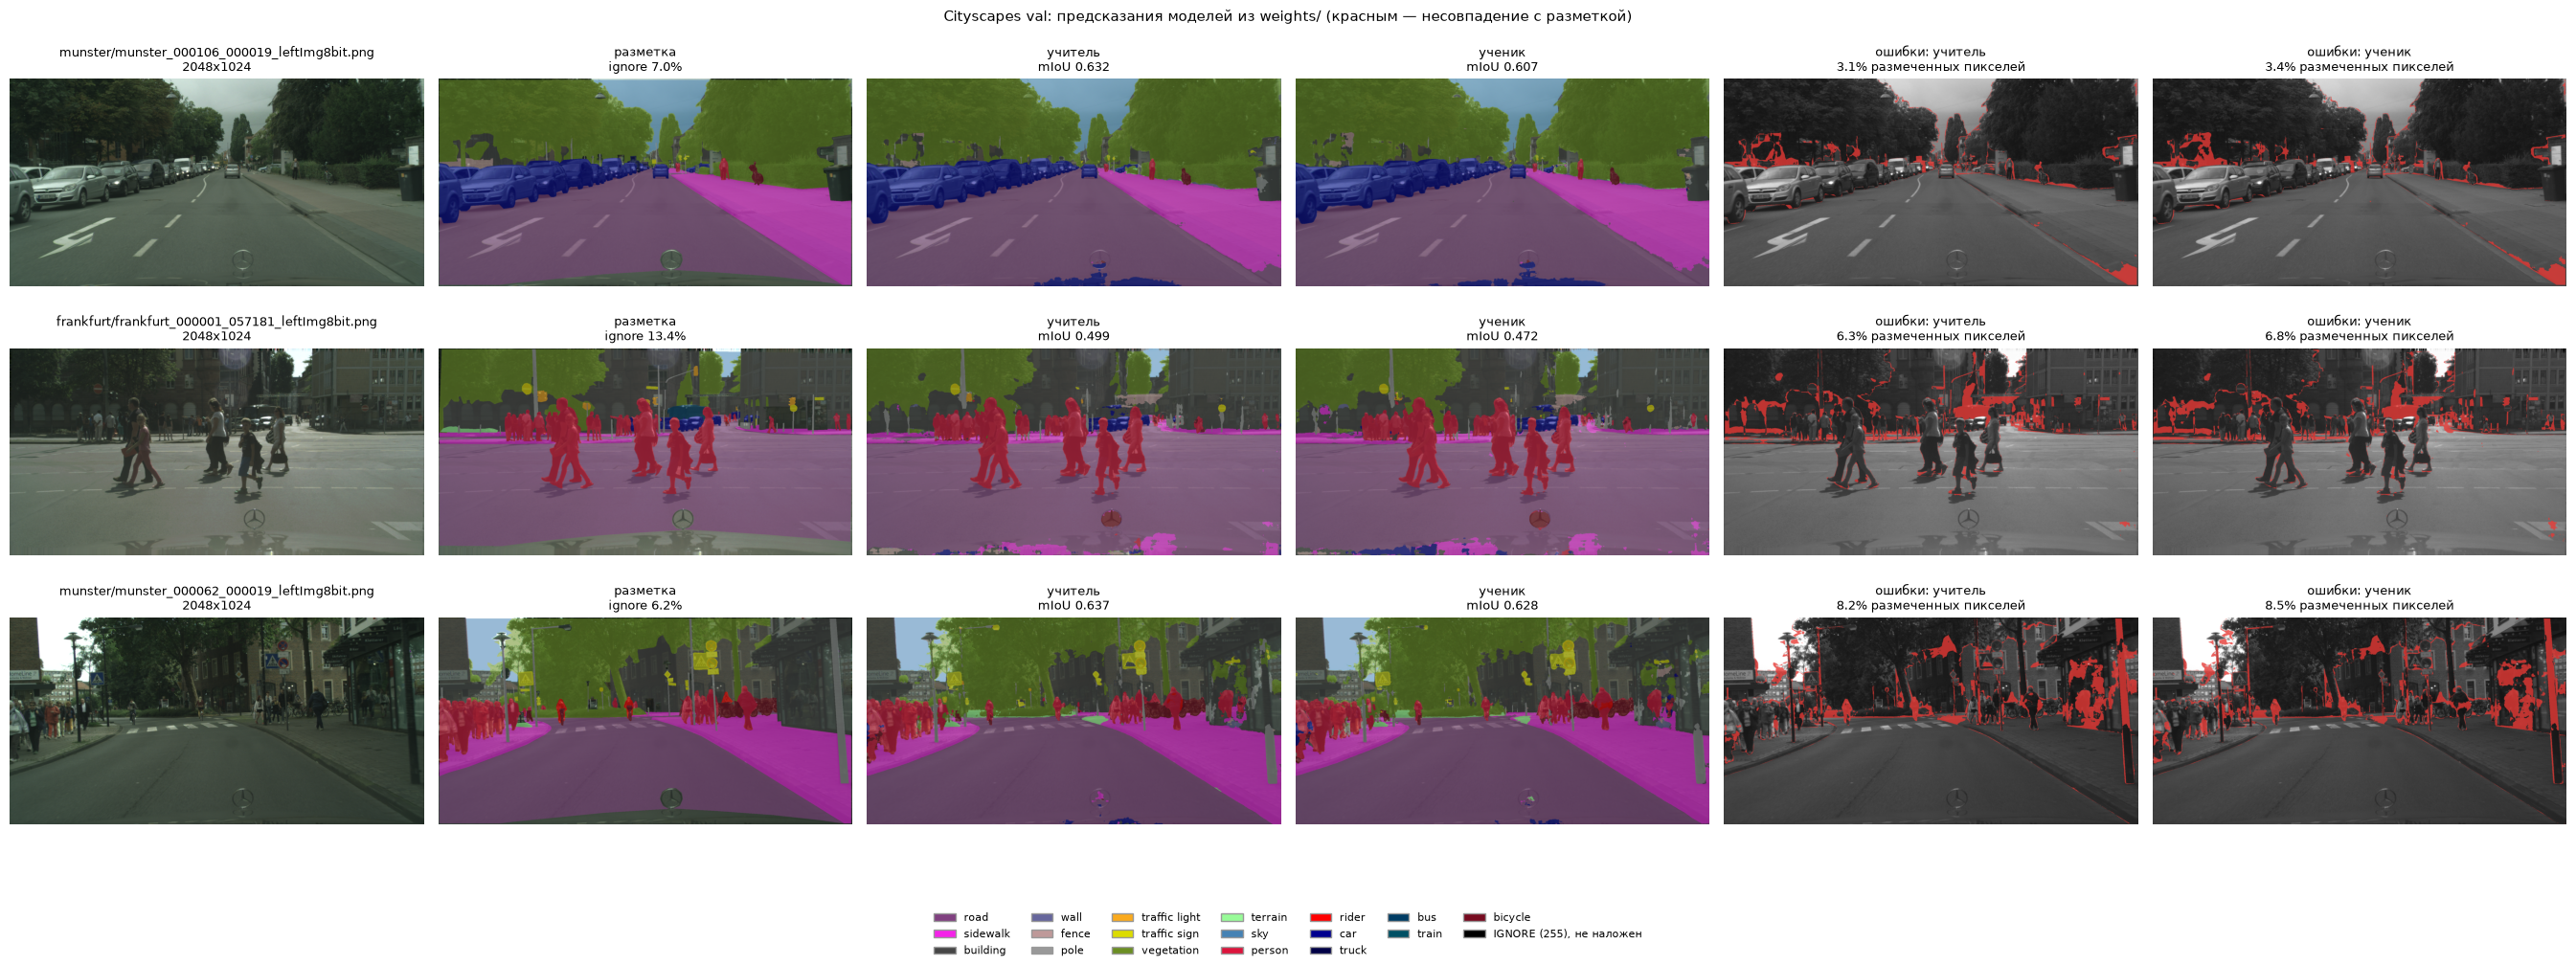

In [25]:
def show_predictions(samples, alpha: float = ALPHA, legend: str = LEGEND, show_errors: bool = SHOW_ERRORS):
    model_titles = list(models)
    with_errors = show_errors and HAS_MASKS

    present_train_ids: set[int] = set()
    rows = []

    for sample in samples:
        image = to_uint8_image(sample["image"], MEAN, STD)
        mask = sample["mask"]
        height, width = image.shape[:2]

        panels = [(image, f"{sample['name']}\n{width}x{height}")]

        if mask is not None:
            present_train_ids.update(mask_class_shares(mask))
            valid = (mask != IGNORE_INDEX).cpu().numpy()
            ignore_share = 100 * float((~valid).mean())
            panels.append(
                (
                    blend(image, colorize_mask(mask, LUT), alpha, valid),
                    f"разметка\nignore {ignore_share:.1f}%",
                )
            )

        for title in model_titles:
            prediction = sample["predictions"][title]
            present_train_ids.update(mask_class_shares(prediction))

            subtitle = (
                f"mIoU {sample['metrics'][title]['miou']:.3f}"
                if title in sample["metrics"]
                else "без разметки"
            )
            panels.append((blend(image, colorize_mask(prediction, LUT), alpha), f"{title}\n{subtitle}"))

        if with_errors:
            for title in model_titles:
                picture, share = error_overlay(
                    image, sample["predictions"][title], mask, IGNORE_INDEX
                )
                panels.append((picture, f"ошибки: {title}\n{share:.1f}% размеченных пикселей"))

        rows.append(panels)

    # Размер фигуры — по реальным пропорциям панелей: при шести колонках
    # фиксированная высота строки приводит к наезду заголовков на картинки.
    panel_width = 4.5
    aspect = max(picture.shape[0] / picture.shape[1] for panels in rows for picture, _ in panels)

    figure, axes = plt.subplots(
        len(rows),
        len(rows[0]),
        figsize=(panel_width * len(rows[0]), (panel_width * aspect + 0.9) * len(rows) + 0.7),
        squeeze=False,
    )

    for row, panels in enumerate(rows):
        for column, (picture, title) in enumerate(panels):
            axis = axes[row][column]
            axis.imshow(picture)
            axis.set_title(title, fontsize=9)
            axis.axis("off")

    source = f"Cityscapes {SPLIT}" if HAS_MASKS else str(IMAGES_DIR)
    figure.suptitle(
        f"{source}: предсказания моделей из {WEIGHTS_ROOT.name}/ "
        f"(красным — несовпадение с разметкой)"
        if with_errors
        else f"{source}: предсказания моделей из {WEIGHTS_ROOT.name}/",
        fontsize=11,
    )

    if legend == "none":
        figure.tight_layout()
    else:
        train_ids = (
            list(range(len(CITYSCAPES_SEGMENTATION_CLASSES)))
            if legend == "all"
            else sorted(train_id for train_id in present_train_ids if train_id != IGNORE_INDEX)
        )
        add_class_legend(figure, train_ids, IGNORE_INDEX)
        figure.tight_layout(rect=(0, 0.06 + 0.01 * (len(train_ids) // 7), 1, 1))

    return figure


figure = show_predictions(samples)
plt.show()

## Метрики по показанным картинкам

Считается по тем же предсказаниям, что на картинках выше: confusion matrix
копится по всем показанным изображениям сразу, поэтому это честный mIoU по
выборке, а не среднее покартиночных mIoU (они смещены — редкий класс на одном
кадре весит столько же, сколько дорога на другом).

Выборка маленькая: это диагностика, а не замена `scripts/eval.py`.

In [26]:
if not HAS_MASKS:
    print("Разметки нет — метрики не считаются.")
else:
    accumulators = {
        title: IoUAccumulator(NUM_CLASSES, torch.device("cpu"), IGNORE_INDEX) for title in models
    }

    for sample in samples:
        for title, prediction in sample["predictions"].items():
            accumulators[title].update(prediction, sample["mask"])

    summary = pd.DataFrame(
        [
            {"модель": title, **{key: round(value, 4) for key, value in accumulator.compute().items()}}
            for title, accumulator in accumulators.items()
        ]
    )
    display(summary)

    per_class = pd.DataFrame(
        {title: accumulator.per_class_iou().numpy() for title, accumulator in accumulators.items()},
        index=list(CITYSCAPES_SEGMENTATION_CLASSES),
    )
    # Класс, которого нет в разметке выборки, даёт IoU = 0 «по неявке» — не показываем.
    present = np.zeros(NUM_CLASSES, dtype=bool)
    for sample in samples:
        for train_id in mask_class_shares(sample["mask"]):
            if 0 <= train_id < NUM_CLASSES:
                present[train_id] = True

    per_class = per_class[present]
    display(per_class.round(4))

,модель,miou,pixel_acc
0,учитель,0.5209,0.9417
1,ученик,0.5018,0.9378


,учитель,ученик
road,0.9806,0.9781
sidewalk,0.9037,0.8919
building,0.7939,0.7895
fence,0.1410,0.0754
pole,0.3696,0.3318
traffic light,0.1686,0.0566
traffic sign,0.7075,0.7053
vegetation,0.9024,0.9009
terrain,0.0805,0.0879
sky,0.9376,0.9312


### IoU по классам

Здесь видно то, чего не видно в одном числе mIoU: у ученика обычно проседают
редкие и мелкие классы (`pole`, `traffic light`, `rider`), а не дорога и небо.

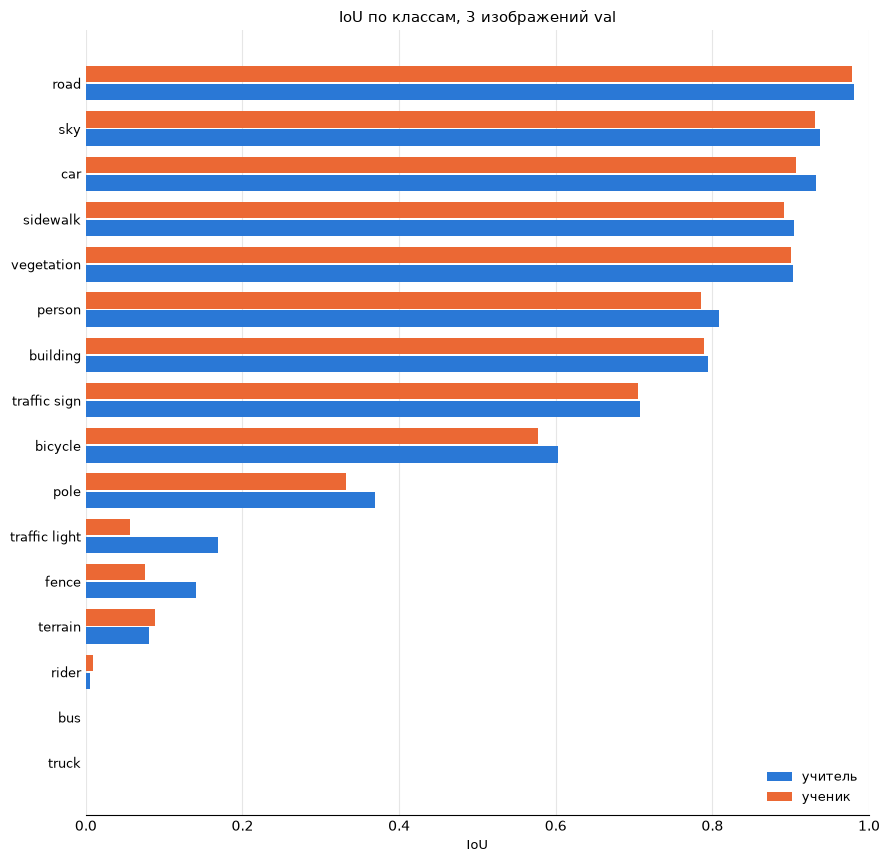

In [27]:
if HAS_MASKS and len(per_class) > 0:
    titles = list(per_class.columns)
    order = per_class[titles[0]].sort_values().index
    positions = np.arange(len(order))
    height = 0.8 / len(titles)

    figure, axis = plt.subplots(figsize=(9, 0.42 * len(order) + 2))

    for number, title in enumerate(titles):
        axis.barh(
            positions + (number - (len(titles) - 1) / 2) * height,
            per_class.loc[order, title].to_numpy(),
            height=height * 0.9,
            color=SERIES_COLORS[number % len(SERIES_COLORS)],
            label=title,
        )

    axis.set_yticks(positions)
    axis.set_yticklabels(order, fontsize=9)
    axis.set_xlabel("IoU", fontsize=9)
    axis.set_xlim(0, 1)
    axis.set_title(f"IoU по классам, {len(samples)} изображений {SPLIT}", fontsize=11)
    axis.grid(axis="x", color="0.9", linewidth=0.8)
    axis.set_axisbelow(True)
    for side in ("top", "right", "left"):
        axis.spines[side].set_visible(False)
    axis.tick_params(length=0)

    # Одна серия называется в заголовке; легенда нужна с двух моделей.
    if len(titles) > 1:
        axis.legend(fontsize=9, frameon=False, loc="lower right")

    figure.tight_layout()
    plt.show()

## Сохранение

In [28]:
if SAVE_PATH is not None:
    save_path = Path(SAVE_PATH)
    if not save_path.is_absolute():
        save_path = REPO_ROOT / save_path

    save_path.parent.mkdir(parents=True, exist_ok=True)
    figure = show_predictions(samples)
    figure.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.close(figure)
    print("Сохранено:", save_path)
else:
    print("SAVE_PATH = None — файл не сохранялся")

SAVE_PATH = None — файл не сохранялся
